<table align="left">
  <td>
    <a target="_blank" href="https://drive.google.com/file/d/11Y_eImNPB3Uq9rsF23nLpk9_X7hYqM1M/view?usp=sharing"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />구글 코랩에서 실행하기</a>
  </td>
</table>

### 데이터 출처
- [서울시 대중교통 O-D 데이터](https://data.seoul.go.kr/dataList/OA-20501/L/1/datasetView.do)

In [ ]:
import pandas as pd
import geopandas as gpd
import os

##### 데이터 정제

In [ ]:
# 위경도 데이터(자체 제작) - geocoding한 데이터
geo_data = gpd.read_file('./od_data/geo_data.shp', encoding="UTF-8")
geo_data

In [ ]:
path = './result/'
# pq.write_table(geo_data, os.path.join(path, 'locations.parquet'))

geo_data[['field1','lon','lat']].to_parquet(os.path.join(path + 'locations.parquet'))

In [ ]:
# od 데이터
od_data = pd.read_csv("./data/동별_목적OD_20240430.csv", encoding = 'cp949')
od_data.head()

In [ ]:
##### 위경도 데이터를 붙이기 위해서 #####
# 출발 구동과 도착 구동 생성
od_data['출발_주소'] = od_data['출발_구'] + ' ' + od_data['출발_동']
od_data['도착_주소'] = od_data['도착_구'] + ' ' + od_data['도착_동']

# 필요한 컬럼만 선택
od_data = od_data[['출발_주소','도착_주소','총_승객수']]
od_data.head()

# "서울시외 서울시외"인 행 제거
od_data = od_data[~((od_data['출발_주소'] == '서울시외 서울시외') | (od_data['도착_주소'] == '서울시외 서울시외'))]


코드 작성을 위한 프롬프트

- od_data가 있음. 출발_주소, 도착_주소, 총_승객수 컬럼이 존재함
- geo_data가 있음.  각 주소에 대한 위경도 좌표가 있음. field1, lon,lat, geometry라는 컬럼이 존재함
- 원하는 작업: od_data에 geo_data에 있는 정보를 merge해서, 출발_주소, 도착_주소 위경도 값을 join하고 싶다. 최종적으로 start_lon, start_lat, end_lon, end_lat을 od_data에 만들어주고 싶어. 

In [ ]:
od_data

In [ ]:
geo_data

In [ ]:
# 출발지 주소를 기준으로 위경도 추가
od_data = od_data.merge(geo_data.drop(columns=['geometry']).
                        rename(columns={'field1': '출발_주소', 'lon': 'start_lon', 'lat': 'start_lat'}),
                        on='출발_주소', how='left')

# 도착지 주소를 기준으로 위경도 추가
od_data = od_data.merge(geo_data.drop(columns=['geometry']).rename(columns={'field1': '도착_주소', 'lon': 'end_lon', 'lat': 'end_lat'}),
                        on='도착_주소', how='left')

# 결과 확인
od_data

In [ ]:
od_data.to_parquet(os.path.join(path + 'flows.parquet'))

##### flowmap 사이트
https://www.flowmap.city/

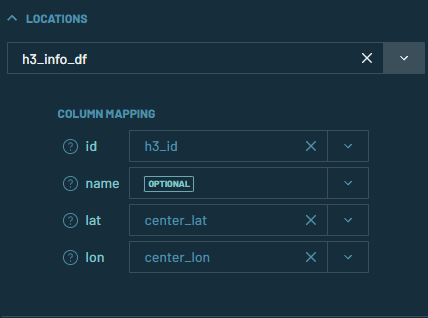  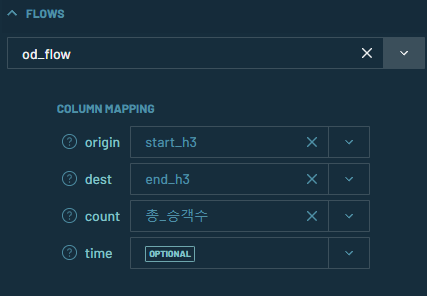

시각화 결과
- https://app.flowmap.city/project/726229c2-6464-4d99-a086-2a7005c6011b